This .ipynb file centers around training a pre-trained ModernBERT model for classifying the number of stars given to products out of five, based on their written reviews. This is done by using a dataset of Amazon product reviews. For creativity, our idea was to train the model in three stages of string types: product category + review title + review, review title + review, review

Firstly, change the runtime type to GPU if it's not set already.
Next, do what's written in the first code below:

In [ ]:
#install transformers library directly from huggingface's github
%pip install "git+https://github.com/huggingface/transformers.git@6e0515e99c39444caae39472ee1b2fd76ece32f1" --upgrade

  Cloning https://github.com/huggingface/transformers.git (to revision 6e0515e99c39444caae39472ee1b2fd76ece32f1) to /tmp/pip-req-build-0h3k_ss0
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers.git /tmp/pip-req-build-0h3k_ss0
  Running command git rev-parse -q --verify 'sha^6e0515e99c39444caae39472ee1b2fd76ece32f1'
  Running command git fetch -q https://github.com/huggingface/transformers.git 6e0515e99c39444caae39472ee1b2fd76ece32f1
  Running command git checkout -q 6e0515e99c39444caae39472ee1b2fd76ece32f1
  Resolved https://github.com/huggingface/transformers.git to commit 6e0515e99c39444caae39472ee1b2fd76ece32f1
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for transformers: filename=transformers-4.48.0.dev0-py3-none-any.whl size=10328690 sha256=ab8ff76d13bfa2e781bb6c36d83280d77360b6ed707c8cc0c6fe011ca911bcaa
  Stored in directory: 

In [ ]:
#import libraries and download dataset from kagglehub
import kagglehub
path = kagglehub.dataset_download("mexwell/amazon-reviews-multi")
print(path)
#This is a dataset containing 210000 english amazon product reviews, with each review having features: review body, product category, star rating, and review title.

/kaggle/input/amazon-reviews-multi


In [ ]:
#load training and testing datasets into dataframes
import pandas as pd
train=pd.read_csv(path+"/train.csv")
test=pd.read_csv(path+"/test.csv")
validation=pd.read_csv(path+"/validation.csv")

#join them into one dataframe
Ds=pd.concat([train,test,validation])


#remove non-english reviews
Ds = Ds[Ds['language'] == "en"]

In [ ]:
#randomly shuffle the dataset
from sklearn.utils import shuffle
Ds = shuffle(Ds,random_state=42)

In [ ]:
#For training, create two new features in train dataset
#"tr" means title concatenated with review
#"ctr" means product category concatenated with tr
#The idea is to train the model on ctr, then tr, then just on review_body, to help it learn the particularities in the reviews of different product categories.
Ds["tr"]=Ds["review_title"]+". "+Ds["review_body"]
Ds["ctr"]=Ds["product_category"]+". "+Ds["tr"]

In [ ]:
#We'll remove all reviews where "ctr" is longer than 200, as google colab could disconnect us if we take too much time on long reviews, based
#on our trial and error. Also, the original dataset is perfectly balanced in the number of reviews with different star-ratings, so using the dataset like this shouldn't be a problem
import pandas as pd

def remove_long_strings(df, column_name, max_length):
    """
    Removes rows from a DataFrame where the string in a specified column
    exceeds a maximum length.

    Args:
        df (pd.DataFrame): The input DataFrame.
        column_name (str): The name of the column to check.
        max_length (int): The maximum allowed length of the string.

    Returns:
        pd.DataFrame: A new DataFrame with rows removed.
    """
    return df[df[column_name].str.len() <= max_length]


max_len = 200
Ds = remove_long_strings(Ds, 'ctr', max_len)

In [ ]:
print(Ds)

        Unnamed: 0   review_id          product_id          reviewer_id  \
394949      394949  en_0679701  product_en_0212429  reviewer_en_0407925   
361875      361875  en_0337685  product_en_0220672  reviewer_en_0350520   
215981      215981  en_0906616  product_en_0101872  reviewer_en_0749518   
330133      330133  en_0884443  product_en_0170054  reviewer_en_0199386   
376588      376588  en_0119329  product_en_0730003  reviewer_en_0460870   
...            ...         ...                 ...                  ...   
287498      287498  en_0952836  product_en_0062183  reviewer_en_0628657   
337337      337337  en_0118676  product_en_0246815  reviewer_en_0783695   
310268      310268  en_0392180  product_en_0499810  reviewer_en_0266197   
303694      303694  en_0325374  product_en_0582106  reviewer_en_0670240   
321958      321958  en_0762057  product_en_0415610  reviewer_en_0310057   

        stars                                        review_body  \
394949      5  These are good t

In [ ]:
#Create three new datasets for three different training stages, and a dataset for testing
train=Ds
train1=pd.DataFrame()
train2=pd.DataFrame()
train3=pd.DataFrame()
test=pd.DataFrame()

train1["stars"]=train["stars"]
train2["stars"]=train["stars"]
train3["stars"]=train["stars"]
test["stars"]=train["stars"]
train1["ctr"]=train["ctr"]
train2["tr"]=train["tr"]
train3["review_body"]=train["review_body"]
test["review_body"]=train["review_body"]



In [ ]:
#We'll make the ratio of dataset sizes 9:2:6, as all other ratios seem to give about the same accuracy and we'll just use this one if it matches their's because we used the most reviews with it. We'll also make the training data in the datasets disjoint,
# so we'll isolate the first 18000 reviews from train1, the next 4000 reviews from train2, and the third 12000 reviews from train3.
train1=train1[0:18000]
train2=train2[18000:22000]
train3=train3[22000:34000]
test=Ds[44200:126955] #We'll use test for evaluating model after training


Now onto creating the model.

In [ ]:
#import necessary libraries
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, ModernBertForSequenceClassification, AdamW, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from tqdm.auto import tqdm

In [ ]:
# Create labels (0-indexed for PyTorch)
train1['label'] = train1['stars'] - 1
train1=train1.drop(["stars"],axis=1)
train2['label'] = train2['stars'] - 1
train2=train2.drop(["stars"],axis=1)
train3['label'] = train3['stars'] - 1
train3=train3.drop(["stars"],axis=1)

eval['label'] = eval['stars'] - 1


test['label'] = test['stars'] - 1



<ipython-input-12-3327598134>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eval['label'] = eval['stars'] - 1
<ipython-input-12-3327598134>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['label'] = test['stars'] - 1


In [ ]:

#convert to lists because the AI chatbot did so as well.
train1_texts = train1['ctr'].tolist()
train1_labels = train1['label'].tolist()


train2_texts = train2['tr'].tolist()
train2_labels = train2['label'].tolist()


train3_texts = train3['review_body'].tolist()
train3_labels = train3['label'].tolist()


test_texts = test['review_body'].tolist()
test_labels = test['label'].tolist()


KeyError: 'label'

In [ ]:
# 2. Tokenization and Dataset Creation
model_name = "answerdotai/ModernBERT-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/20.8k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.13M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

In [ ]:
class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [ ]:
#Training phase

max_len = 200  # max number of tokens
train_dataset = ReviewDataset(train1_texts, train1_labels, tokenizer, max_len)

batch_size = 16  # Batch size during training
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# 3. Load the Model with the Correct Number of Labels
num_labels = 5  # For the 5 star ratings
model = ModernBertForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

# Move the model to the GPU if available in Colab
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Using device: {device}")

# 4. Set Up Optimizer and Learning Rate Scheduler
epochs = 3  # You can increase this in Colab for better results
learning_rate = 5e-5
warmup_steps = 0.1 * len(train_dataloader)
total_steps = len(train_dataloader) * epochs

optimizer = AdamW(model.parameters(), lr=learning_rate)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

# 5. Training Loop
progress_bar = tqdm(range(total_steps), desc="Training")

model.train()
for epoch in range(epochs):
    print(f"Epoch {epoch+1}")
    for batch in train_dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()

        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        progress_bar.update(1)

print("First training phase complete.")

config.json:   0%|          | 0.00/1.19k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Some weights of ModernBertForSequenceClassification were not initialized from the model checkpoint at answerdotai/ModernBERT-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Using device: cuda


/usr/local/lib/python3.11/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Training:   0%|          | 0/27000 [00:00<?, ?it/s]

Epoch 1


W0601 13:56:54.624000 1156 torch/_inductor/utils.py:1137] [1/0] Not enough SMs to use max_autotune_gemm mode


In [ ]:
#Train the same model again, but now on the second training dataset

train_dataset = ReviewDataset(train2_texts, train2_labels, tokenizer, max_len)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# 5. Training Loop
progress_bar = tqdm(range(total_steps), desc="Training")

model.train()
for epoch in range(epochs):
    print(f"Epoch {epoch+1}")
    for batch in train_dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()

        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        progress_bar.update(1)

print("Second training phase complete.")


Training:   0%|          | 0/939 [00:00<?, ?it/s]

Epoch 1
Epoch 2
Epoch 3


In [ ]:
#Train on third dataset

train_dataset = ReviewDataset(train3_texts, train3_labels, tokenizer, max_len)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# 5. Training Loop
progress_bar = tqdm(range(total_steps), desc="Training")

model.train()
for epoch in range(epochs):
    print(f"Epoch {epoch+1}")
    for batch in train_dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()

        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        progress_bar.update(1)

print("Third training phase complete.")

NameError: name 'ReviewDataset' is not defined

In [ ]:
#Function for making the model classify sentiment in a string given to the function
def predict_star_rating(review_text):
    """
    Predicts the Amazon star rating (1-5) for a given review text using the trained ModernBERT model.

    Args:
        review_text (str): The text of the product review.

    Returns:
        int: The predicted star rating (1 to 5).
    """
    inputs = tokenizer(review_text, return_tensors="pt", truncation=True, padding=True, max_length=128)
    inputs = inputs.to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits

    predicted_class = torch.argmax(logits, dim=-1).item()
    # Add 1 to the predicted class to get the star rating (0-indexed to 1-indexed)
    predicted_star_rating = predicted_class + 1
    return predicted_star_rating

In [ ]:
#We'll use this for making a confusion matrix.
#g is the list of the model's predictions on the first 10000 reviews from test
g=[predict_star_rating(i) for i in test["review_body"][0:10000]]

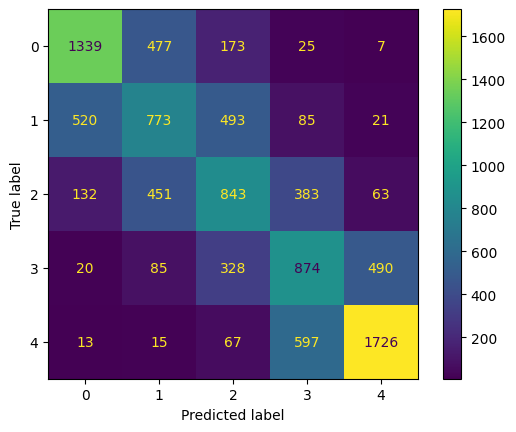

In [ ]:
#plot confusion matrix for first 10000 reviews from test dataset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC


cm = confusion_matrix(g, list(test["stars"][0:10000]))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [ ]:
#Load google drive for saving the model
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 7. Save the Trained Model (to Google Drive if needed)
output_dir = "./modernbert_star_rating_classifier5"
model.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)
print(f"\nModernBERT star rating classifier saved to '{output_dir}'")

# to save to Google Drive:
output_dir_drive = "/content/drive/MyDrive/modernbert_star_rating_classifier5"
model.save_pretrained(output_dir_drive)
tokenizer.save_pretrained(output_dir_drive)
print(f"\nModernBERT star rating classifier saved to Google Drive at '{output_dir_drive}'")


ModernBERT star rating classifier saved to './modernbert_star_rating_classifier5'

ModernBERT star rating classifier saved to Google Drive at '/content/drive/MyDrive/modernbert_star_rating_classifier5'


In [ ]:
#This is code for loading the model from outside colab

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from google.colab import drive
import os

# --- Configuration ---
# IMPORTANT: Replace 'your_model_folder_name' with the actual name of the folder
# where you saved your model and tokenizer files within your Google Drive.
# For example, if you saved them in 'My Drive/my_bert_model_v1/', then
# model_save_folder = 'my_bert_model_v1'
model_save_folder = 'modernbert_star_rating_classifier6'

# Path to the root of your Google Drive
gdrive_root_path = '/content/drive/MyDrive/'

# Full path to your saved model and tokenizer directory
model_full_path = os.path.join(gdrive_root_path, model_save_folder)

# Define the number of labels, this MUST match what your model was trained with
# Based on your previous code, this was 5 for 5-star ratings.
num_labels = 5

# --- Step 1: Mount Google Drive ---
print("Mounting Google Drive...")
drive.mount('/content/drive')
print("Google Drive mounted.")

# --- Step 2: Verify the Model Directory Exists ---
if not os.path.isdir(model_full_path):
    print(f"\nERROR: The directory '{model_full_path}' does not exist.")
    print("Please double-check the 'model_save_folder' variable to ensure it matches")
    print("the exact folder name in your Google Drive where you saved the model files.")
    print("Example: if your model files are in 'My Drive/my_awesome_bert/', set model_save_folder = 'my_awesome_bert'.")
else:
    print(f"\nFound model directory: {model_full_path}")
    print("Attempting to load model and tokenizer...")

    # --- Step 3: Load the Tokenizer ---
    try:
        tokenizer = AutoTokenizer.from_pretrained(model_full_path)
        print("Tokenizer loaded successfully!")
    except Exception as e:
        print(f"Error loading tokenizer: {e}")
        print("Please ensure 'tokenizer_config.json', 'special_tokens_map.json', and 'tokenizer.json'")
        print(f"are present in: {model_full_path}")
        tokenizer = None # Set to None to indicate failure

    # --- Step 4: Load the Model ---
    try:
        # AutoModelForSequenceClassification will look for config.json and model.safetensors
        model = AutoModelForSequenceClassification.from_pretrained(model_full_path, num_labels=num_labels)
        print("Model loaded successfully!")
    except Exception as e:
        print(f"Error loading model: {e}")
        print("Please ensure 'config.json' and 'model.safetensors' (or 'pytorch_model.bin')")
        print(f"are present in: {model_full_path}")
        model = None # Set to None to indicate failure

    # --- Step 5: Move Model to GPU (if available) ---
    if model is not None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model.to(device)
        print(f"Model moved to device: {device}")
    else:
        print("Model was not loaded due to previous error, skipping device transfer.")

# --- Verify Loading (Optional) ---
if tokenizer is not None and model is not None:
    print("\n--- Model and Tokenizer are ready for use ---")
    print(f"Example Tokenizer test: {tokenizer.decode(tokenizer('Hello world!', return_tensors='pt')['input_ids'][0])}")

    # You can now put the model in evaluation mode if you plan to do inference
    # model.eval()
    # Or keep it in train mode if you plan to continue training
    # model.train()
else:
    print("\n--- Model or Tokenizer failed to load. Please check errors above. ---")

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted.

Found model directory: /content/drive/MyDrive/modernbert_star_rating_classifier6
Attempting to load model and tokenizer...
Tokenizer loaded successfully!
Model loaded successfully!
Model moved to device: cuda

--- Model and Tokenizer are ready for use ---
Example Tokenizer test: [CLS]Hello world![SEP]
